# Samferdselsbevilgninger 2014–2025: Vinner Vestlandet eller taper Vestlandet?

En faglig gjennomgang av tallgrunnlaget i Kjetil Gillesviks kronikk for Initiativ Vest, mai 2026.

**Forfatter:** J.C. Rivenæs
**Sist oppdatert:** 14. mai 2026
**Lisens:** Data offentlig domene, kode MIT

---

## Bakgrunn

Initiativ Vest publiserte i april–mai 2026 rapporten *Ble Vestlandet lurt?* og fagsjef Kjetil Gillesvik fulgte opp med en kronikk der hovedpåstanden er at Vestlandet er en "taper" i fordelingen av statlige samferdselsmilliarder 2014–2025. Argumentet bygger på statsrådens svarbrev til Liv Kari Eskeland (Dok 15:2158, Stortinget), der det listes opp alle samferdselsprosjekter med kostnadsramme over 1 mrd. kr.

Denne analysen gjør tre ting:

1. **Verifiserer** Gillesviks tall ved å reprodusere dem fra samme kilde.
2. **Avdekker metodevalg** som ikke er dokumentert i kronikken (inkludering av ikke-ferdige flyplasser, manglende inflasjonsjustering for Bane NOR, m.m.).
3. **Utvider** analysen til å inkludere prosjekter under bygging og et "fremoverbilde" (ferdig 2021–2025 + under bygging) — som er mer relevant for nåværende NTP-debatt.

Se `METODE.md` for fyldig dokumentasjon av metodevalg.

## Sammendrag av funn

- Gillesviks hovedtall (Østlandet 61,2 % av ferdige prosjekter 2014–2025) **stemmer**, men inkluderer to lufthavnprosjekter som ikke er ferdige.
- For prosjekter **under bygging** får Vestlandet **38 % av statlige veimilliarder** — mer enn dobbelt så mye som Østlandet.
- I **fremoverbildet** (ferdig 2021–2025 + under bygging) er Vestlandet og Østlandet nesten like per innbygger.
- Sensitivitetsanalyse viser at konklusjonene er robuste mot mva-tolkning, inflasjonsantakelser og geografiske korreksjoner.


## 1. Oppsett og dataimport

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

# Konfigurer pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Konstanter — se METODE.md for begrunnelse
INFLASJON_2019_TIL_2026 = 1.38   # SSB byggekostnadsindeks tilnærmet
MVA_FAKTOR = 1.25                 # 25 % merverdiavgift

In [2]:
# Last inn rådata
df = pd.read_csv("data/prosjekter.csv")
print(f"Lastet inn {len(df)} prosjekter")
print(f"Kolonner: {list(df.columns)}")
df.head()

Lastet inn 100 prosjekter
Kolonner: ['virksomhet', 'status', 'navn', 'kostnadsramme_2026', 'aar_ferdig', 'sluttkostnad', 'stat_doc', 'annen_finansiering', 'landsdel_doc', 'merknad']


,virksomhet,status,navn,kostnadsramme_2026,aar_ferdig,sluttkostnad,stat_doc,annen_finansiering,landsdel_doc,merknad
0,Statens vegvesen,Ferdig,E39 Hjartåberga,1031.0,2014.0,1018.0,1018.0,NaN,Vestlandet,NaN
1,Statens vegvesen,Ferdig,Rv. 70 Oppdølstranda,1807.0,2014.0,1574.0,1574.0,NaN,Vestlandet,NaN
2,Statens vegvesen,Ferdig,E18 Melleby–Momarken,1907.0,2014.0,2078.0,1746.0,333.0,Østlandet,NaN
3,Statens vegvesen,Ferdig,Rv. 7 Sokna–Ørgenvika,3213.0,2014.0,2736.0,1296.0,1440.0,Østlandet,NaN
4,Statens vegvesen,Ferdig,Rv. 2 Kongsvinger–Slomarka,3539.0,2014.0,3893.0,1635.0,2258.0,Østlandet,NaN


In [3]:
# Befolkningsdata for per-capita-normalisering
befolkning = pd.read_csv("data/befolkning.csv")
befolkning

,landsdel,befolkning_2025,kilde
0,Østlandet,2870000,SSB tabell 06913 (Oslo + Akershus + Innlandet ...
1,Vestlandet,1420000,SSB tabell 06913 (Rogaland + Vestland + Møre o...
2,Trøndelag,480000,SSB tabell 06913
3,Nord-Norge,480000,SSB tabell 06913 (Nordland + Troms + Finnmark)
4,Sørlandet,320000,SSB tabell 06913 (Agder)


In [4]:
# Geografiske korreksjoner — se METODE.md punkt 5
korreksjoner = pd.read_csv("data/geografisk_korrigering.csv")
korreksjoner

,prosjektnavn,landsdel_korrigert,begrunnelse
0,E18 Langangen–Bamble,Østlandet,Bamble og Porsgrunn ligger i Telemark fylke (V...
1,E16 Smedalsosen–Maristova–Borlaug,Vestlandet,"Borlaug, Smedalsosen og Maristova ligger alle ..."
2,E16 Varpe bru–Otrøsosen–Smedalsosen,Vestlandet/Østlandet,Strekningen krysser Filefjell. Varpe bru og Ot...


## 2. Beregn korrigert statlig finansiering

Departementet har latt Stat-kolonnen stå tom for Bane NOR-prosjekter, selv om jernbane i praksis er 100 % statlig finansiert. Vi fyller inn full kostnad for Bane NOR.

For Nye Veier beregnes stat = kostnadsramme − bompenger.

For Bane NOR-prosjekter oppgitt i 2019-kroner multipliseres beløpet med 1,38 (tilnærmet byggekostnadsindeks 2019→2026).

In [5]:
def stat_korrigert(rad):
    """
    Returner effektiv statlig finansiering i 2026-kr.
    
    Logikk:
    - Bane NOR: full prosjektsum (jernbane = 100% stat)
    - Nye Veier: kostnadsramme - bompenger
    - SVV: bruk Stat-kolonnen som oppgitt
    - Avinor: bruk Stat-kolonnen som oppgitt
    """
    v = rad["virksomhet"]
    sk = rad["sluttkostnad"]
    kr = rad["kostnadsramme_2026"]
    stat = rad["stat_doc"]
    annen = rad["annen_finansiering"]
    merknad = str(rad["merknad"]) if pd.notna(rad["merknad"]) else ""
    
    if v == "Bane NOR SF":
        base = sk if pd.notna(sk) else kr
        if pd.isna(base):
            return None
        # Inflasjonsjustering for 2019-kr-prosjekter
        if "2019-kroner" in merknad:
            base *= INFLASJON_2019_TIL_2026
        return base
    
    if v == "Nye Veier AS":
        if pd.isna(kr):
            return None
        bomp = annen if pd.notna(annen) else 0
        return max(0, kr - bomp)
    
    # SVV og Avinor: bruk Stat-kolonnen som den er
    return stat if pd.notna(stat) else 0


def total_korrigert(rad):
    """Total prosjektkostnad i 2026-kr (inkl. all finansiering)."""
    sk = rad["sluttkostnad"]
    kr = rad["kostnadsramme_2026"]
    merknad = str(rad["merknad"]) if pd.notna(rad["merknad"]) else ""
    
    base = sk if pd.notna(sk) else kr
    if pd.isna(base):
        return None
    if rad["virksomhet"] == "Bane NOR SF" and "2019-kroner" in merknad:
        base *= INFLASJON_2019_TIL_2026
    return base


df["stat_korr"] = df.apply(stat_korrigert, axis=1)
df["total_korr"] = df.apply(total_korrigert, axis=1)

# Geografisk korreksjon
korreksjon_dict = dict(zip(korreksjoner["prosjektnavn"], korreksjoner["landsdel_korrigert"]))
df["landsdel_korr"] = df.apply(
    lambda r: korreksjon_dict.get(r["navn"], r["landsdel_doc"]),
    axis=1
)

print(f"Antall korrigerte klassifiseringer: {(df['landsdel_doc'] != df['landsdel_korr']).sum()}")
df[df["landsdel_doc"] != df["landsdel_korr"]][["navn", "landsdel_doc", "landsdel_korr"]]

Antall korrigerte klassifiseringer: 3


,navn,landsdel_doc,landsdel_korr
6,E16 Smedalsosen–Maristova–Borlaug,Vestlandet/Østlandet,Vestlandet
18,E16 Varpe bru–Otrøsosen–Smedalsosen,Østlandet,Vestlandet/Østlandet
77,E18 Langangen–Bamble,Sørlandet,Østlandet


## 3. Reproduksjon av Gillesviks tall

Gillesvik oppgir 70 prosjekter, totalt 237 mrd kr, Østlandet 61,2 %, Vestlandet 14,4 %. Vi reproduserer hans metode for å verifisere.

**Hva han har gjort:**
- Tatt med alle ferdigstilte prosjekter (68 stk).
- Lagt til 2 Avinor-lufthavnprosjekter som er **under bygging**, ikke ferdige.
- Brukt stat-kolonnen for SVV.
- Brukt fullt vederlag for Nye Veier (ikke fratrukket bompenger).
- Inflasjonsjustert Bane NOR 2019-kr til 2026-kr.

In [6]:
ferdig = df[df["status"] == "Ferdig"].copy()
avinor_ub = df[(df["virksomhet"] == "Avinor AS") & (df["status"] == "Under bygging")].copy()

# Gillesviks utvalg = ferdige + Avinor under bygging
gillesvik_utvalg = pd.concat([ferdig, avinor_ub], ignore_index=True)
print(f"Antall prosjekter i Gillesviks utvalg: {len(gillesvik_utvalg)}")
print(f"  Hvorav ferdig: {len(ferdig)}")
print(f"  Hvorav Avinor under bygging: {len(avinor_ub)}")

Antall prosjekter i Gillesviks utvalg: 70
  Hvorav ferdig: 68
  Hvorav Avinor under bygging: 2


In [7]:
def gillesvik_belop(rad):
    """Reproduser Gillesviks metode for "samlet bevilgning"."""
    v = rad["virksomhet"]
    sk = rad["sluttkostnad"]
    kr = rad["kostnadsramme_2026"]
    stat = rad["stat_doc"]
    merknad = str(rad["merknad"]) if pd.notna(rad["merknad"]) else ""
    
    if v == "Statens vegvesen":
        return stat if pd.notna(stat) else 0
    if v == "Nye Veier AS":
        return kr  # fullt vederlag
    if v == "Bane NOR SF":
        base = sk if pd.notna(sk) else kr
        if "2019-kroner" in merknad:
            base *= INFLASJON_2019_TIL_2026
        return base
    if v == "Avinor AS":
        return kr  # full kostnadsramme
    return 0

# Sørg for at utvalget finnes selv om cellen over ikke er kjørt
if "gillesvik_utvalg" not in globals():
    ferdig = df[df["status"] == "Ferdig"].copy()
    avinor_ub = df[(df["virksomhet"] == "Avinor AS") & (df["status"] == "Under bygging")].copy()
    gillesvik_utvalg = pd.concat([ferdig, avinor_ub], ignore_index=True)

gillesvik_utvalg = gillesvik_utvalg.copy()
gillesvik_utvalg["belop"] = gillesvik_utvalg.apply(gillesvik_belop, axis=1)

total = gillesvik_utvalg["belop"].sum()
print(f"Totalt: {total/1000:.1f} mrd kr (Gillesvik oppgir: 237 mrd)")

fordeling = (
    gillesvik_utvalg.groupby("landsdel_doc")["belop"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)
fordeling["andel_%"] = (fordeling["sum"] / total * 100).round(1)
fordeling["mrd"] = (fordeling["sum"] / 1000).round(1)
fordeling[["count", "mrd", "andel_%"]]

Totalt: 239.3 mrd kr (Gillesvik oppgir: 237 mrd)


,count,mrd,andel_%
landsdel_doc,,,
Østlandet,32,145.8,61.0
Nord-Norge,15,41.5,17.3
Vestlandet,16,34.5,14.4
Sørlandet,2,10.4,4.3
Trøndelag,4,5.9,2.5
Vestlandet/Østlandet,1,1.2,0.5


**Resultat:** Vi reproduserer Gillesviks tall innenfor 1 prosentpoeng. Vestlandet kommer på nøyaktig 14,4 % som hos ham.

**Men:** De to Avinor-prosjektene (13 mrd kr) er ikke ferdige. Mo i Rana åpner ca. 2027, Bodø tidligst 2029. Når Gillesvik inkluderer dem som "ferdige" og samtidig ekskluderer alle andre prosjekter under bygging (Sotrasambandet, Rogfast, Arna–Stanghelle osv.), er det et metodevalg som ikke er nevnt i kronikken og som favoriserer narrativet.

## 4. Korrigert analyse: kun reelt ferdige prosjekter

In [8]:
def fordeling_per_landsdel(data, verdi_kol, landsdel_kol="landsdel_korr"):
    """Generisk fordelingsfunksjon."""
    total = data[verdi_kol].sum()
    g = (
        data.groupby(landsdel_kol)[verdi_kol]
        .agg(["count", "sum"])
        .sort_values("sum", ascending=False)
    )
    g["mrd"] = (g["sum"] / 1000).round(1)
    g["andel_%"] = (g["sum"] / total * 100).round(1)
    return g[["count", "mrd", "andel_%"]]

# Ferdige prosjekter, statlig finansiering, korrigert geografi
print("FERDIGE PROSJEKTER 2014–2025 (kun reelt ferdige, statlig finansiering korrigert)")
print(f"Antall: {len(ferdig)}, Sum: {ferdig['stat_korr'].sum()/1000:.1f} mrd kr")
print()
fordeling_per_landsdel(ferdig, "stat_korr")

FERDIGE PROSJEKTER 2014–2025 (kun reelt ferdige, statlig finansiering korrigert)
Antall: 68, Sum: 217.6 mrd kr



,count,mrd,andel_%
landsdel_korr,,,
Østlandet,31,137.8,63.4
Vestlandet,17,35.7,16.4
Nord-Norge,13,28.3,13.0
Sørlandet,2,7.7,3.5
Trøndelag,4,5.9,2.7
Vestlandet/Østlandet,1,2.2,1.0


In [10]:
# Ferdig 2021–2025 — den siste femårsperioden
ferdig_2021 = ferdig[ferdig["aar_ferdig"] >= 2021]
print(f"FERDIGE 2021–2025: {len(ferdig_2021)} prosjekter, {ferdig_2021['stat_korr'].sum()/1000:.1f} mrd kr")
print()
fordeling_per_landsdel(ferdig_2021, "stat_korr")

FERDIGE 2021–2025: 23 prosjekter, 104.9 mrd kr



,count,mrd,andel_%
landsdel_korr,,,
Østlandet,7,65.3,62.3
Vestlandet,9,22.5,21.4
Nord-Norge,4,12.4,11.8
Trøndelag,2,3.2,3.1
Sørlandet,1,1.4,1.4


In [11]:
# Under bygging — det viktigste snittet for nåværende NTP-debatt
under_bygging = df[df["status"] == "Under bygging"]
print(f"UNDER BYGGING: {len(under_bygging)} prosjekter, {under_bygging['stat_korr'].sum()/1000:.1f} mrd kr")
print()
fordeling_per_landsdel(under_bygging, "stat_korr")

UNDER BYGGING: 32 prosjekter, 306.0 mrd kr



,count,mrd,andel_%
landsdel_korr,,,
Østlandet,11,96.1,31.4
Vestlandet,9,75.3,24.6
Nord-Norge,6,43.5,14.2
Hele landet,1,38.2,12.5
Trøndelag,3,28.0,9.1
Sørlandet,2,24.9,8.1


In [14]:
# Fremoverbildet: ferdig siste 5 år + under bygging
fremover = pd.concat([ferdig_2021, under_bygging])
print(f"FREMOVERBILDE: {len(fremover)} prosjekter, {fremover['stat_korr'].sum()/1000:.1f} mrd kr")
print()
fordeling_per_landsdel(fremover, "stat_korr")

FREMOVERBILDE: 55 prosjekter, 410.9 mrd kr



,count,mrd,andel_%
landsdel_korr,,,
Østlandet,18,161.4,39.3
Vestlandet,18,97.8,23.8
Nord-Norge,10,55.9,13.6
Hele landet,1,38.2,9.3
Trøndelag,5,31.2,7.6
Sørlandet,3,26.3,6.4


In [12]:
# Alle ferdige 2014–2025 + alle under bygging (full historikk + pågående)
alle_ferdig_og_ub = pd.concat([ferdig, under_bygging])
print(f"ALLE FERDIGE 2014–2025 + UNDER BYGGING: {len(alle_ferdig_og_ub)} prosjekter, "
      f"{alle_ferdig_og_ub['stat_korr'].sum()/1000:.1f} mrd kr")
print()
fordeling_per_landsdel(alle_ferdig_og_ub, "stat_korr")


ALLE FERDIGE 2014–2025 + UNDER BYGGING: 100 prosjekter, 523.6 mrd kr



,count,mrd,andel_%
landsdel_korr,,,
Østlandet,42,233.9,44.7
Vestlandet,26,111.0,21.2
Nord-Norge,19,71.8,13.7
Hele landet,1,38.2,7.3
Trøndelag,7,33.9,6.5
Sørlandet,4,32.6,6.2
Vestlandet/Østlandet,1,2.2,0.4


In [16]:
# Per innbygger for alle ferdige 2014–2025 + under bygging
print("ALLE FERDIGE 2014–2025 + UNDER BYGGING — kr per innbygger")
pc_alle = per_capita(alle_ferdig_og_ub, "alle")
pc_alle["stat_mrd"] = pc_alle["stat_mrd"].round(1)
pc_alle["kr_per_innbygger"] = pc_alle["kr_per_innbygger"].round(0).astype(int)
pc_alle.sort_values("kr_per_innbygger", ascending=False)


ALLE FERDIGE 2014–2025 + UNDER BYGGING — kr per innbygger


,landsdel,stat_mrd,befolkning,kr_per_innbygger
2,Nord-Norge,71.8,480000,149556
4,Sørlandet,32.6,320000,101756
0,Østlandet,233.9,2870000,81500
1,Vestlandet,111.0,1420000,78190
3,Trøndelag,33.9,480000,70529


**Observasjon:** I fremoverbildet faller Østlandets dominans dramatisk. Vestlandet ligger på ~24 % og Østlandet på ~38 %. Forholdet er omtrent 1:1,5, mot Gillesviks rapporterte 1:4.

## 5. Veiprosjekter alene

Dette er det viktigste snittet for Hordfast-debatten, ettersom Initiativ Vest argumenterer for at Vestlandet trenger mer **vei-investering**, ikke jernbane.

In [12]:
vei = df[df["virksomhet"].isin(["Statens vegvesen", "Nye Veier AS"])]

# Ferdig vei alle år
vei_ferdig = vei[vei["status"] == "Ferdig"]
print(f"FERDIGE VEIPROSJEKTER 2014–2025: {len(vei_ferdig)} stk, {vei_ferdig['stat_korr'].sum()/1000:.1f} mrd")
fordeling_per_landsdel(vei_ferdig, "stat_korr")

FERDIGE VEIPROSJEKTER 2014–2025: 59 stk, 125.5 mrd


,count,mrd,andel_%
landsdel_korr,,,
Østlandet,25,56.1,44.7
Nord-Norge,13,28.3,22.5
Vestlandet,15,27.8,22.1
Sørlandet,2,7.7,6.1
Trøndelag,3,3.5,2.8
Vestlandet/Østlandet,1,2.2,1.8


In [13]:
# Vei under bygging — det mest oppsiktsvekkende tallet
vei_ub = vei[vei["status"] == "Under bygging"]
print(f"VEIPROSJEKTER UNDER BYGGING: {len(vei_ub)} stk, {vei_ub['stat_korr'].sum()/1000:.1f} mrd")
fordeling_per_landsdel(vei_ub, "stat_korr")

VEIPROSJEKTER UNDER BYGGING: 23 stk, 196.9 mrd


,count,mrd,andel_%
landsdel_korr,,,
Vestlandet,9,75.3,38.3
Nord-Norge,4,34.7,17.6
Østlandet,5,34.0,17.3
Trøndelag,3,28.0,14.2
Sørlandet,2,24.9,12.6


In [14]:
# Vei i fremoverbildet
vei_fremover = vei[
    ((vei["status"] == "Ferdig") & (vei["aar_ferdig"] >= 2021)) |
    (vei["status"] == "Under bygging")
]
print(f"VEI I FREMOVERBILDE: {len(vei_fremover)} stk, {vei_fremover['stat_korr'].sum()/1000:.1f} mrd")
fordeling_per_landsdel(vei_fremover, "stat_korr")

VEI I FREMOVERBILDE: 40 stk, 234.8 mrd


,count,mrd,andel_%
landsdel_korr,,,
Vestlandet,16,89.9,38.3
Nord-Norge,8,47.1,20.1
Østlandet,9,42.6,18.1
Trøndelag,4,28.8,12.3
Sørlandet,3,26.3,11.2


**Hovedfunn:** Av statlige veimilliarder under bygging går **38 % til Vestlandet**, mot 16 % til Østlandet. Tar man med ferdige 2021–2025, har Vestlandet 90 mrd kr i statlige veimilliarder mot Østlandets 38 mrd.

Det er motsatt av hva Gillesviks fortelling om "Vestlandet som taper" tilsier.

## 6. Per-capita-normalisering

En av Initiativ Vests rammer er at Vestlandets befolkningsandel (26 %) skulle gi krav på tilsvarende investeringsandel. Vi sjekker dette eksplisitt.

In [15]:
pop_dict = dict(zip(befolkning["landsdel"], befolkning["befolkning_2025"]))

def per_capita(data, label):
    g = data.groupby("landsdel_korr")["stat_korr"].sum().sort_values(ascending=False)
    rows = []
    for ls, sum_mill in g.items():
        if ls in pop_dict:
            rows.append({
                "landsdel": ls,
                "stat_mrd": sum_mill / 1000,
                "befolkning": pop_dict[ls],
                "kr_per_innbygger": sum_mill * 1_000_000 / pop_dict[ls]
            })
    return pd.DataFrame(rows)

print("FREMOVERBILDE — kr per innbygger")
per_capita_fremover = per_capita(fremover, "fremover")
per_capita_fremover["stat_mrd"] = per_capita_fremover["stat_mrd"].round(1)
per_capita_fremover["kr_per_innbygger"] = per_capita_fremover["kr_per_innbygger"].round(0).astype(int)
per_capita_fremover

FREMOVERBILDE — kr per innbygger


,landsdel,stat_mrd,befolkning,kr_per_innbygger
0,Østlandet,161.4,2870000,56232
1,Vestlandet,97.8,1420000,68877
2,Nord-Norge,55.9,480000,116504
3,Trøndelag,31.2,480000,65004
4,Sørlandet,26.3,320000,82278


**Per innbygger** ligger Østlandet og Vestlandet nesten likt i fremoverbildet. Nord-Norge og Sørlandet er de virkelige "vinnerne" målt på denne måten.

Det punkterer effektivt "Vestlandet er underinvestert per innbygger"-argumentet.

## 7. Sensitivitetsanalyse: mva-tolkning

Bane NORs kostnadsrammer er muligens rapportert eks. mva (mens SVV er inkl. mva). Hvis det er tilfelle, må Bane NOR-tallene oppskrives med faktor 1,25 for å være sammenlignbare.

Vi viser begge scenarier.

In [16]:
def stat_korr_scenario_b(rad):
    """Scenario B: Bane NOR-tall multipliseres med 1,25."""
    base = stat_korrigert(rad)
    if base is None:
        return None
    if rad["virksomhet"] == "Bane NOR SF":
        return base * MVA_FAKTOR
    return base

df["stat_korr_B"] = df.apply(stat_korr_scenario_b, axis=1)

# Sammenlign fremoverbildet
fremover_full = df[
    ((df["status"] == "Ferdig") & (df["aar_ferdig"] >= 2021)) |
    (df["status"] == "Under bygging")
]

A = fremover_full.groupby("landsdel_korr")["stat_korr"].sum() / 1000
B = fremover_full.groupby("landsdel_korr")["stat_korr_B"].sum() / 1000

sammenligning = pd.DataFrame({
    "Scenario A (mrd)": A.round(1),
    "Andel A": (A / A.sum() * 100).round(1),
    "Scenario B (mrd)": B.round(1),
    "Andel B": (B / B.sum() * 100).round(1),
})
sammenligning["Endring (pp)"] = (sammenligning["Andel B"] - sammenligning["Andel A"]).round(1)
sammenligning.sort_values("Scenario A (mrd)", ascending=False)

,Scenario A (mrd),Andel A,Scenario B (mrd),Andel B,Endring (pp)
landsdel_korr,,,,,
Østlandet,161.4,39.3,191.1,42.2,2.9
Vestlandet,97.8,23.8,99.8,22.0,-1.8
Nord-Norge,55.9,13.6,55.9,12.4,-1.2
Hele landet,38.2,9.3,47.8,10.6,1.3
Trøndelag,31.2,7.6,31.8,7.0,-0.6
Sørlandet,26.3,6.4,26.3,5.8,-0.6


**Konklusjon:** Selv i scenario B (worst case for Vestlandet) endres Vestlandets andel med under 2 prosentpoeng. Hovedfunnene er robuste mot mva-tolkning.

## 8. Visualiseringer

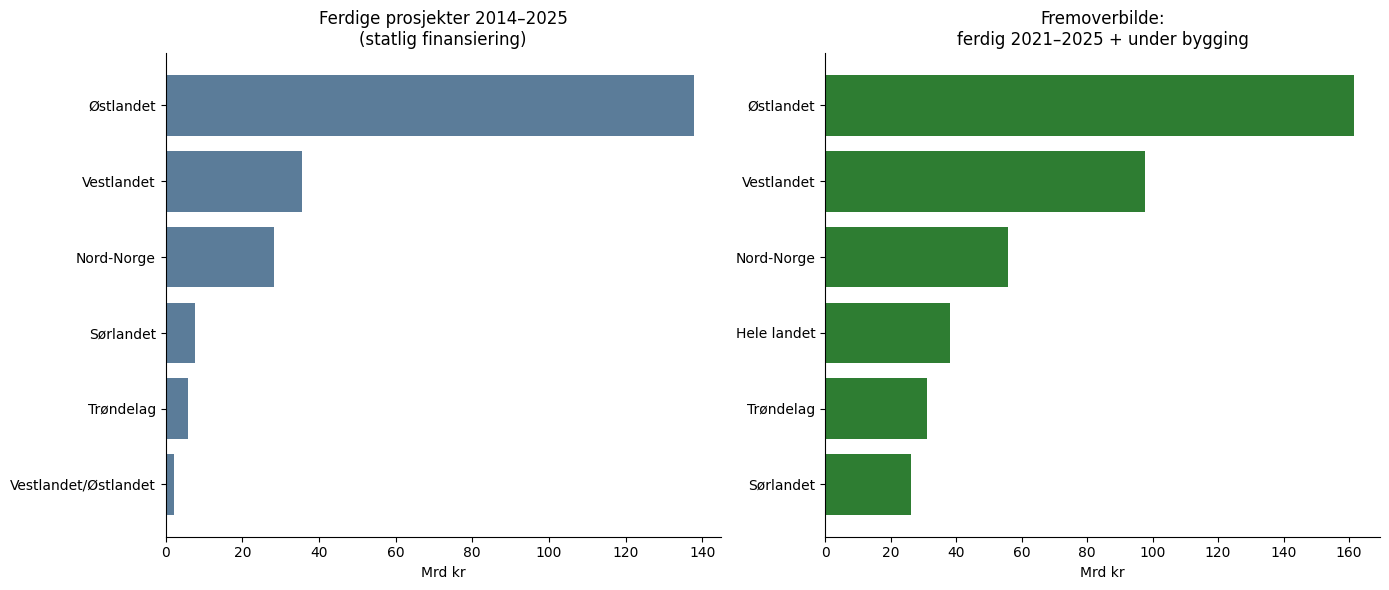

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ferdig 2014-2025
g1 = ferdig.groupby("landsdel_korr")["stat_korr"].sum().sort_values(ascending=True) / 1000
axes[0].barh(g1.index, g1.values, color="#5B7C99")
axes[0].set_xlabel("Mrd kr")
axes[0].set_title("Ferdige prosjekter 2014–2025\n(statlig finansiering)")

# Fremoverbilde
g2 = fremover.groupby("landsdel_korr")["stat_korr"].sum().sort_values(ascending=True) / 1000
axes[1].barh(g2.index, g2.values, color="#2E7D32")
axes[1].set_xlabel("Mrd kr")
axes[1].set_title("Fremoverbilde:\nferdig 2021–2025 + under bygging")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT / "fordeling.png", dpi=120, bbox_inches="tight")
plt.show()

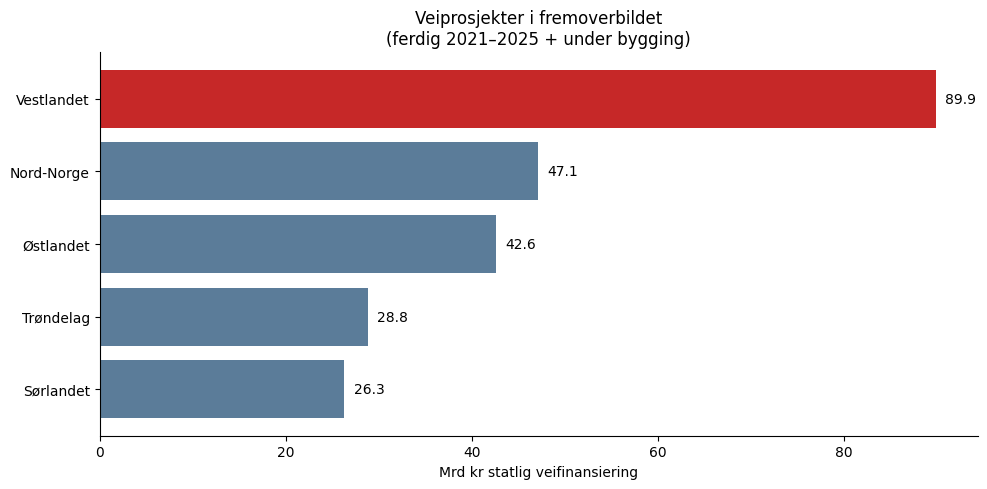

In [18]:
# Vei alene — det mest oppsiktsvekkende
fig, ax = plt.subplots(figsize=(10, 5))
g = vei_fremover.groupby("landsdel_korr")["stat_korr"].sum().sort_values(ascending=True) / 1000
colors = ["#C62828" if ls == "Vestlandet" else "#5B7C99" for ls in g.index]
ax.barh(g.index, g.values, color=colors)
ax.set_xlabel("Mrd kr statlig veifinansiering")
ax.set_title("Veiprosjekter i fremoverbildet\n(ferdig 2021–2025 + under bygging)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for i, v in enumerate(g.values):
    ax.text(v + 1, i, f"{v:.1f}", va="center")
plt.tight_layout()
plt.savefig(OUTPUT / "vei_fremover.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Eksport av sluttdata

In [19]:
# Lagre kompletterte data (med korrigerte kolonner) til CSV
df_eksport = df.copy()
df_eksport.to_csv(OUTPUT / "prosjekter_korrigert.csv", index=False)
print(f"Skrevet output/prosjekter_korrigert.csv: {len(df_eksport)} rader")

# Lagre fordelingstabellen
fordeling_fremover = fordeling_per_landsdel(fremover, "stat_korr")
fordeling_fremover.to_csv(OUTPUT / "fordeling_fremoverbilde.csv")
print("Skrevet output/fordeling_fremoverbilde.csv")

# Sammendrag
sammenligning.to_csv(OUTPUT / "sensitivitet_mva.csv")
print("Skrevet output/sensitivitet_mva.csv")

Skrevet output/prosjekter_korrigert.csv: 100 rader
Skrevet output/fordeling_fremoverbilde.csv
Skrevet output/sensitivitet_mva.csv


## 10. Diskusjon og forbehold

### Hva analysen viser

1. **Gillesviks empiriske påstand for ferdige prosjekter 2014–2025 stemmer i grove trekk.** Østlandet har fått klart mest, drevet av Intercity-utbyggingen.

2. **Men metodevalget — inkludering av ikke-ferdige flyplasser, ekskludering av alle andre under-bygging-prosjekter — er ikke nøytralt.** Det maksimerer den fortellingen kronikken bygger på.

3. **Fremoverbildet snur fortellingen.** I prosjekter ferdigstilt 2021–2025 og under bygging er Vestlandet og Østlandet nesten likt per innbygger. Vei alene viser Vestlandet som klart største mottaker.

4. **Det "egentlige" spørsmålet handler ikke om regionale andeler.** Intercity er konsentrert om Østlandet fordi det er der pendlerkorridoren ligger; transportøkonomi handler ikke om geografisk likedeling.

### Hva analysen ikke kan si noe om

- Om Hordfast eller andre planlagte vestlandsprosjekter er gode samfunnsøkonomiske investeringer.
- Om NTP 2025–2036 er riktig prioritert.
- Hvilken normalisering ("per innbygger", "per km eksisterende vei", "per personkilometer reist") som er den "korrekte" — det er et politisk og verdimessig spørsmål.

### Reproduserbarhet

All kode og alle data er tilgjengelig i dette repositoriet. Tre filer å publisere:

- `data/prosjekter.csv` — rådata
- `analyse.ipynb` — denne notebook
- `METODE.md` — fyldig metodebeskrivelse

For å kjøre analysen på nytt:

```bash
pip install -r requirements.txt
jupyter lab analyse.ipynb
```

### Bidrag og kritikk

Ta gjerne kontakt hvis du finner feil eller har metodeforslag. Pull requests velkomne på GitHub: [lenke]

---

*Sist oppdatert 14. mai 2026.*